# Unidad 2 · Procesamiento y transformación de datos

**Qué vas a aprender**
- Pasar de datos "crudos" a una tabla lista para analizar: elegir, filtrar, ordenar y crear columnas.
- Agrupar y resumir: por moneda, por año, por día de la semana.
- Cambiar entre formato **largo** y **ancho**, unir tablas y decidir qué hacer con los datos que faltan.
- Dejar preparado el conjunto de datos que usan los modelos de las unidades siguientes.

El temario hace esta unidad en R con `dplyr`. Este cuaderno hace **lo mismo con pandas**, y el cuaderno
de R de la unidad, lo mismo con `dplyr`: compáralos lado a lado. Las operaciones tienen nombres
distintos, pero son las mismas ideas:

| Tarea | R (`dplyr`, `tidyr`) | Python (`pandas`) |
|---|---|---|
| leer un CSV | `read_csv()` | `pd.read_csv()` |
| elegir columnas | `select()` | `df[["a", "b"]]` |
| filtrar filas | `filter()` | `df[condición]` o `df.query()` |
| ordenar | `arrange()` | `df.sort_values()` |
| crear una columna | `mutate()` | `df.assign()` o `df["x"] = ...` |
| agrupar y resumir | `group_by() + summarise()` | `df.groupby().agg()` |
| ancho ↔ largo | `pivot_wider()` / `pivot_longer()` | `df.pivot()` / `df.melt()` |
| unir tablas | `inner_join()` / `full_join()` | `pd.merge()` / `df.join()` |
| el valor de ayer | `lag()` | `df.shift()` |

**Qué tiene que ver con la app.** La pantalla **Mi diario** del piloto valora tu cartera día a día: une
lo que tienes con los precios de cada día. Al final de este cuaderno la construyes tú.

In [1]:
#@title Preparación: ejecuta esta celda primero (▶). Carga los precios de Binance.
# Es la misma en todos los cuadernos. Cómo se construye se explica en la Unidad 1.
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)
plt.rcParams.update({"figure.figsize": (11, 4), "axes.grid": True, "grid.alpha": 0.3})

ACTIVOS = ["BTC", "ETH", "SOL"]        # las monedas de la cartera de ejemplo del piloto
COLORES = {"BTC": "#F7931A", "ETH": "#627EEA", "SOL": "#9945FF"}
DESDE = "2020-01-01"                    # el piloto también mira desde 2020
HASTA = "2026-09-26"                    # fija las cifras del texto; None = hasta ayer
ANUAL = 365                             # las criptos cotizan todos los días del año
API = "https://data-api.binance.vision/api/v3/klines"   # api.binance.com bloquea Colab


def descargar(simbolo, desde=DESDE):
    """Velas diarias YA CERRADAS de SIMBOLO/USDT en Binance, 1000 por petición."""
    inicio = int(pd.Timestamp(desde, tz="UTC").timestamp() * 1000)
    filas = []
    while True:
        r = requests.get(API, params={"symbol": f"{simbolo}USDT", "interval": "1d",
                                      "startTime": inicio, "limit": 1000}, timeout=30)
        r.raise_for_status()
        lote = r.json()
        filas += lote
        if len(lote) < 1000:
            break
        inicio = lote[-1][0] + 1                      # la página siguiente empieza tras la última vela
    crudo = pd.DataFrame([f[:7] for f in filas],
                         columns=["apertura_ms", "open", "high", "low", "close", "volume", "cierre_ms"])
    crudo = crudo[crudo["cierre_ms"] < pd.Timestamp.now(tz="UTC").timestamp() * 1000]
    df = pd.DataFrame({"fecha": pd.to_datetime(crudo["apertura_ms"], unit="ms", utc=True)})
    for c in ["open", "high", "low", "close", "volume"]:
        df[c] = crudo[c].astype(float).to_numpy()
    return df.drop_duplicates("fecha").reset_index(drop=True)


def velas(simbolo):
    """Velas diarias del periodo de estudio: del CSV si ya está, si no de Binance (y lo guarda)."""
    archivo = f"{simbolo}USDT_1d.csv"
    hoy = pd.Timestamp.now(tz="UTC").normalize()
    fin = pd.Timestamp(HASTA, tz="UTC") if HASTA else hoy - pd.Timedelta(days=1)
    df = None
    if os.path.exists(archivo):
        df = pd.read_csv(archivo)
        df["fecha"] = pd.to_datetime(df["fecha"], utc=True)
    if df is None or df["fecha"].max() < fin:
        try:
            df = descargar(simbolo)
            df.to_csv(archivo, index=False, date_format="%Y-%m-%dT%H:%M:%SZ")
        except requests.RequestException as e:
            if df is None:
                raise RuntimeError(f"No pude descargar {simbolo} de Binance ({e}). Sube {archivo} "
                                   "(carpeta de datos de respaldo del curso) y repite.") from None
            print(f"Aviso: sin conexión con Binance; {archivo} llega solo al {df['fecha'].max():%d-%m-%Y}.")
    df = df[(df["fecha"] >= pd.Timestamp(DESDE, tz="UTC")) & (df["fecha"] <= fin)]
    return df.set_index("fecha")


def cierres(activos=ACTIVOS):
    """Cierres diarios, una columna por moneda: la tabla con la que trabaja el piloto."""
    return pd.DataFrame({a: velas(a)["close"] for a in activos})


print(f"Listo. Periodo de estudio: del {DESDE} al {HASTA or 'día de ayer'}.")

Listo. Periodo de estudio: del 2020-01-01 al 2026-09-26.


## 1. Importar y juntar en formato largo

`velas()` (en la celda de preparación) lee cada moneda del CSV o la descarga. Para trabajar con las
tres a la vez, se apilan en **formato largo**: una fila por día **y moneda**, con una columna que dice
de qué moneda es cada fila. Es el formato que prefieren `dplyr`, `ggplot2` y `groupby`.

In [2]:
largo = pd.concat([velas(a).reset_index().assign(moneda=a) for a in ACTIVOS], ignore_index=True)
largo = largo[["fecha", "moneda", "open", "high", "low", "close", "volume"]]
largo.info()
largo.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7160 entries, 0 to 7159
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype              
---  ------  --------------  -----              
 0   fecha   7160 non-null   datetime64[ns, UTC]
 1   moneda  7160 non-null   object             
 2   open    7160 non-null   float64            
 3   high    7160 non-null   float64            
 4   low     7160 non-null   float64            
 5   close   7160 non-null   float64            
 6   volume  7160 non-null   float64            
dtypes: datetime64[ns, UTC](1), float64(5), object(1)
memory usage: 391.7+ KB


,fecha,moneda,open,high,low,close,volume
0,2020-01-01 00:00:00+00:00,BTC,7195.24,7255.0,7175.15,7200.85,16792.388165
1,2020-01-02 00:00:00+00:00,BTC,7200.77,7212.5,6924.74,6965.71,31951.483932
2,2020-01-03 00:00:00+00:00,BTC,6965.49,7405.0,6871.04,7344.96,68428.500451
3,2020-01-04 00:00:00+00:00,BTC,7345.00,7404.0,7272.21,7354.11,29987.974977
4,2020-01-05 00:00:00+00:00,BTC,7354.19,7495.0,7318.00,7358.75,38331.085604


## 2. Crear columnas: el rendimiento diario, y un error que hay que ver una vez

El rendimiento simple de un día es `cierre de hoy / cierre de ayer − 1`. En pandas, `pct_change()`.

Cuidado: en formato largo, la fila anterior a la primera de SOL es la **última de ETH**. Si se calcula
sobre toda la tabla, el primer "rendimiento" de SOL compara el precio de SOL con el de ETH. Hay que
calcularlo **por moneda** (`groupby`). Mira la diferencia:

In [3]:
mal = largo["close"].pct_change()
bien = largo.groupby("moneda")["close"].pct_change()
primera_sol = largo.index[largo["moneda"] == "SOL"][0]
print(f"Primer día de SOL, calculado sobre toda la tabla: {mal[primera_sol]:.2%}")
print(f"Primer día de SOL, calculado por moneda:          {bien[primera_sol]}")
largo["ret"] = bien

Primer día de SOL, calculado sobre toda la tabla: -99.88%
Primer día de SOL, calculado por moneda:          nan


El primero es un desplome del 99 % que nunca existió: SOL valía unos 3 dólares y ETH, unos 380.
Un solo dato así arruina una volatilidad o un "peor día". El segundo es `NaN`, que es lo correcto:
el primer día no tiene día anterior.

## 3. Filtrar y ordenar: los peores días

¿Qué días cayó alguna moneda más de un 25 %? Ordenados del peor al menos malo. Hay fechas que
conviene reconocer: el 12-03-2020 (el pánico del COVID), el 19-05-2021 (China contra la minería y el
comercio de criptos) y el 09-11-2022 (la quiebra de FTX, con SOL en el centro).

In [4]:
peores = largo[largo["ret"] < -0.25].sort_values("ret")
peores[["fecha", "moneda", "close", "ret"]].assign(ret=lambda d: d["ret"].map("{:.1%}".format))

,fecha,moneda,close,ret
2532,2020-03-12 00:00:00+00:00,ETH,107.8200,-44.6%
5742,2022-11-09 00:00:00+00:00,SOL,14.0800,-42.2%
71,2020-03-12 00:00:00+00:00,BTC,4800.0000,-39.5%
5203,2021-05-19 00:00:00+00:00,SOL,34.9880,-37.5%
2965,2021-05-19 00:00:00+00:00,ETH,2438.9200,-27.7%
4947,2020-09-05 00:00:00+00:00,SOL,2.6052,-26.2%


## 4. Agrupar y resumir: cada moneda, cada año

`groupby` parte la tabla en grupos y `agg` resume cada uno. Por moneda y año:
- **rentabilidad** del año: se encadenan los rendimientos diarios, `(1 + r).prod() − 1`;
- **volatilidad anual**: la desviación típica diaria por la raíz de 365 (Unidad 6);
- **peor día** y porcentaje de días en que subió.

2020 empieza en agosto para SOL, y 2026 acaba el 26 de septiembre: son años incompletos.

In [5]:
largo["año"] = largo["fecha"].dt.year
anual = largo.groupby(["moneda", "año"])["ret"].agg(
    rentabilidad=lambda r: (1 + r).prod() - 1,
    volatilidad=lambda r: r.std() * np.sqrt(ANUAL),
    peor_dia="min",
    dias_sube=lambda r: (r.dropna() > 0).mean(),
)
anual.map("{:.0%}".format)

rentabilidad volatilidad peor_dia dias_sube
moneda año                                             
BTC    2020         302%         76%     -40%       58%
       2021          60%         81%     -14%       50%
       2022         -64%         64%     -15%       46%
       2023         156%         44%      -7%       50%
       2024         121%         53%      -8%       52%
       2025          -6%         42%      -9%       50%
       2026          -4%         46%     -14%       49%
ETH    2020         463%         99%     -45%       56%
       2021         399%        108%     -28%       56%
       2022         -67%         87%     -17%       48%
       2023          91%         47%      -8%       50%
       2024          46%         65%     -10%       52%
       2025         -11%         75%     -15%       50%
       2026          -9%         63%     -15%       52%
SOL    2020         -54%        174%     -26%       45%
       2021       11178%        164%     -37%       55%
       2022         -94%        117%     -42%       46%
       2023         920%         99%     -12%       50%
       2024          86%         82%     -13%       52%
       2025         -34%         86%     -20%       49%
       2026          -3%         64%     -15%       49%

Lo que dice la tabla:
- La **volatilidad** anual va del 42 % (BTC en 2025) a más del 150 % (SOL en 2020 y 2021). Un índice de
  acciones suele moverse entre un 15 y un 20 % al año.
- La **rentabilidad** de un año a otro va de más del 10 000 % (SOL en 2021) a −94 % (SOL en 2022).
- Los **días de subida** rondan el 50 % todos los años. Ganar o perder un año no depende de subir más
  días, sino de cuánto se sube o se baja en unos pocos.

### Por día de la semana

Los mercados de acciones cierran el fin de semana; las criptos no. ¿Se nota? Se agrupa por día de la
semana el volumen (en dólares: unidades × precio) y el tamaño del movimiento (el valor absoluto del
rendimiento). Para comparar monedas, cada una se divide por su media.

In [6]:
nombres = ["lunes", "martes", "miércoles", "jueves", "viernes", "sábado", "domingo"]
largo["dia"] = pd.Categorical(largo["fecha"].dt.dayofweek.map(dict(enumerate(nombres))), nombres, ordered=True)
largo["volumen_usd"] = largo["volume"] * largo["close"]
semana = largo.groupby(["dia", "moneda"], observed=True).agg(volumen=("volumen_usd", "mean"),
                                                            movimiento=("ret", lambda r: r.abs().mean()))
semana = semana / semana.groupby("moneda").transform("mean")
semana.unstack("moneda").round(2)

volumen             movimiento            
moneda        BTC   ETH   SOL        BTC   ETH   SOL
dia                                                 
lunes        1.14  1.15  1.14       1.24  1.16  1.08
martes       1.13  1.11  1.09       1.04  0.96  0.94
miércoles    1.13  1.12  1.09       1.16  1.17  1.19
jueves       1.09  1.08  1.06       1.14  1.12  1.05
viernes      1.14  1.10  1.09       1.08  1.06  1.11
sábado       0.65  0.69  0.73       0.53  0.68  0.77
domingo      0.71  0.76  0.80       0.80  0.84  0.86

El sábado y el domingo se negocia entre un 20 y un 35 % menos que la media, y los precios se mueven
menos. Esa regularidad semanal reaparece en la Unidad 5 como **estacionalidad**.

## 5. De largo a ancho, y unir tablas

Para comparar monedas día a día (correlaciones, una cartera) conviene el formato **ancho**: una fila
por día y una columna por moneda. `pivot` pasa de largo a ancho; `melt`, de ancho a largo.

In [7]:
ancho = largo.pivot(index="fecha", columns="moneda", values="close")
print(ancho.shape, "| vuelta a largo:", ancho.reset_index().melt(id_vars="fecha").dropna().shape)
ancho.head(3)

(2461, 3) | vuelta a largo: (7160, 3)


moneda,BTC,ETH,SOL
fecha,,,
2020-01-01 00:00:00+00:00,7200.85,130.77,NaN
2020-01-02 00:00:00+00:00,6965.71,127.19,NaN
2020-01-03 00:00:00+00:00,7344.96,134.35,NaN


**Unir** dos tablas por la fecha: con `how="inner"` quedan solo los días que están en las dos; con
`how="outer"`, todos, con huecos donde falte una. Es la diferencia entre `inner_join` y `full_join` en R.

In [8]:
btc = velas("BTC")[["close"]].rename(columns={"close": "BTC"})
sol = velas("SOL")[["close"]].rename(columns={"close": "SOL"})
print("inner:", len(btc.join(sol, how="inner")), "días | outer:", len(btc.join(sol, how="outer")), "días")

inner: 2238 días | outer: 2461 días


## 6. Los datos que faltan

Antes de agosto de 2020 SOL no existía. ¿Qué se hace con esos huecos? Depende de la pregunta:

| Estrategia | Cuándo | Ejemplo en el piloto |
|---|---|---|
| **quitar** las filas (`dropna`) | cuando hacen falta todas las monedas a la vez | la volatilidad de la mezcla usa solo los días comunes |
| **rellenar con el último precio** (`ffill`) | para valorar algo que tienes, si un día falta el precio | "Tiempos duros" rellena días sueltos sin vela |
| rellenar con el **siguiente** (`bfill`) | **nunca** en series de precios | usaría un precio del futuro |

`bfill` es una forma silenciosa de mirar el futuro: el modelo "sabría" un precio antes de que exista.

In [9]:
print("Huecos por moneda:\n", ancho.isna().sum())
comunes = ancho.dropna()
print("Días comunes a las tres:", len(comunes), "desde", comunes.index[0].date())

Huecos por moneda:
 moneda
BTC      0
ETH      0
SOL    223
dtype: int64
Días comunes a las tres: 2238 desde 2020-08-11


## 7. Caso aplicado: datos listos para la econometría

Los modelos de las unidades 4 a 7 trabajan con **rendimientos logarítmicos** diarios (Unidad 3 explica
por qué), en los días comunes y sin huecos. Se guarda la tabla en un CSV para no repetir el proceso.

In [10]:
retornos = np.log(comunes).diff().dropna()
print(retornos.shape, "| huecos:", int(retornos.isna().sum().sum()))
retornos.to_csv("retornos_diarios.csv", date_format="%Y-%m-%d")
retornos.describe().round(4)

(2237, 3) | huecos: 0


moneda,BTC,ETH,SOL
count,2237.0000,2237.0000,2237.0000
mean,0.0009,0.0009,0.0016
std,0.0299,0.0406,0.0595
min,-0.1670,-0.3249,-0.5490
25%,-0.0130,-0.0181,-0.0289
50%,0.0002,0.0012,-0.0003
75%,0.0142,0.0204,0.0298
max,0.1784,0.2338,0.3776


## 8. Así lo usa el piloto: tu cartera, día a día

La cartera de ejemplo del manual del piloto es **0,05 BTC, 1,2 ETH, 10 SOL y 500 USDT**. Para saber
cuánto valía cada día se une lo que tienes (las unidades) con la tabla de precios: cada moneda vale
`unidades × cierre`, y los USDT valen lo que dicen. Es una columna nueva y una suma por fila.

El piloto hace esto en **Mi diario**, con un cuidado más: si compras o vendes, cambia las unidades
desde ese día, y no cuenta los ingresos como ganancias (Unidad 9).

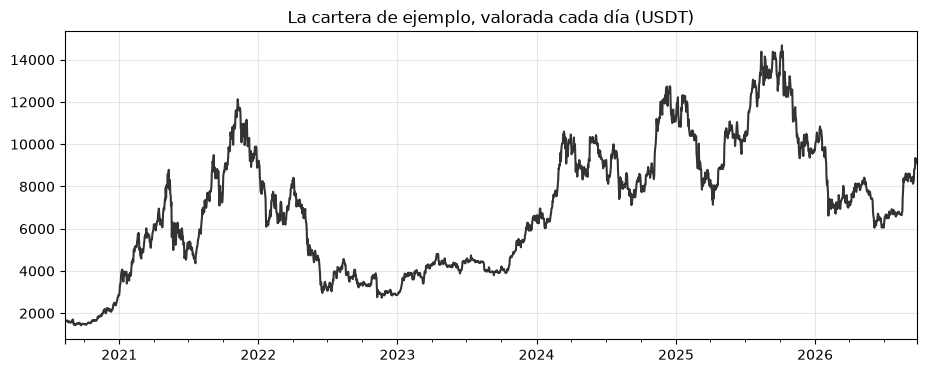

Valor el 26-09-2026: 9,171 USDT
Peso de cada parte: {'BTC': 0.46, 'ETH': 0.353, 'SOL': 0.132, 'USDT': 0.055}


In [11]:
cartera = {"BTC": 0.05, "ETH": 1.2, "SOL": 10.0}
usdt = 500.0
valor_moneda = comunes[list(cartera)] * pd.Series(cartera)    # unidades × cierre, columna a columna
valor = valor_moneda.sum(axis=1) + usdt

ax = valor.plot(title="La cartera de ejemplo, valorada cada día (USDT)", color="#333333")
ax.set_xlabel("")
plt.show()
hoy = valor_moneda.iloc[-1]
print(f"Valor el {valor.index[-1]:%d-%m-%Y}: {valor.iloc[-1]:,.0f} USDT")
print("Peso de cada parte:", (pd.concat([hoy, pd.Series({"USDT": usdt})]) / valor.iloc[-1]).round(3).to_dict())

Y la **caída desde el máximo**: cuánto está la cartera por debajo de lo más alto que ha valido en los
últimos 180 días. El piloto la vigila para su *freno*: si pasa del 10 %, recomienda invertir menos.

In [12]:
maximo_180 = valor.rolling(180, min_periods=1).max()
caida = valor / maximo_180 - 1
print(f"Caída vigente: {caida.iloc[-1]:.1%} | peor caída en el periodo: {caida.min():.1%} ({caida.idxmin():%d-%m-%Y})")

Caída vigente: -1.9% | peor caída en el periodo: -70.1% (18-06-2022)


## Ejercicios

1. **Tu cartera.** Cambia las unidades de `cartera` por otras y repite la sección 8. ¿Qué parte del
   valor está en cada moneda hoy?
2. **Por mes.** Repite la tabla de la sección 4 agrupando por año y mes (`fecha.dt.to_period("M")`).
   ¿Cuál fue el peor mes de BTC?
3. **Domingos.** ¿El rendimiento medio del domingo es distinto del de los demás días? Calcula la media
   y su error típico (`std / √n`) por día de la semana. ¿La diferencia es mayor que dos errores típicos?
4. **El error del `bfill`.** Rellena hacia atrás los precios de SOL antes de agosto de 2020 y calcula la
   volatilidad de la mezcla de las tres desde 2020. ¿Cambia mucho? ¿Por qué es un error de todos modos?